# MACE-OFF23 in xnn: organic chemistry with a pretrained foundation model

`MACE.from_foundation()` turns any published MACE foundation checkpoint into
an ordinary xnn model (verified to float64 round-off in
`examples/fidelity_checks/mace_foundation_verification.ipynb`). This
notebook puts the **MACE-OFF23** organic force field (Kovacs *et al.*,
arXiv:2312.15211; H C N O F P S Cl Br I) to work on three tasks that show
what "an ordinary xnn model" buys:

1. **conformational energetics**, side by side with the classical OPLS-AA
   force field on the butane torsion (the system OPLS was fit to, and a
   nontrivial test for an ML potential trained on equilibrium-ish data);
2. **hydrogen bonding**: the water dimer binding energy and geometry
   against the CCSD(T)/CBS benchmark;
3. **fine-tuning**: the same `Trainer` that fits every xnn model from
   scratch adapts the foundation model to a new reference (rMD17
   malonaldehyde, a *different* DFT functional), cutting its force errors
   by an order of magnitude with 200 structures.

MACE-OFF23 is distributed under the Academic Software License (ASL, no
commercial use); loading it through `from_foundation` prints that notice.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import io
import contextlib
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
rng = np.random.default_rng(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

from ase import Atoms
from ase.constraints import FixInternals
from ase.optimize import BFGS
from scipy.spatial.transform import Rotation

import xnn
from xnn.common.deploy import XNNCalculator
from xnn.common.models import ForceStressOutput
from xnn.gnn.models import MACE

EV_TO_KCAL = 23.060548
print("xnn:", xnn.__version__, "| device:", DEVICE)

xnn: 0.1.0 | device: cuda


## 1. Load the foundation model

One call: the checkpoint is downloaded (or read from the cache), unpickled
with `mace-torch`, and converted weight-for-weight into the xnn `MACE`.
Everything downstream (ASE calculator, autograd forces, TorchScript,
training) is the standard xnn machinery. Float64 keeps the geometry
optimizations below crisp.


In [2]:
torch.set_default_dtype(torch.float64)
off = MACE.from_foundation("mace-off23-small", dtype=torch.float64).to(DEVICE)
print("elements:", off.species)
print(f"r_max = {off.cutoff} A | interaction-energy scale = "
      f"{float(off.scale_shift.scale):.4f} eV")

def off_calc():
    return XNNCalculator(ForceStressOutput(off), cutoff=off.cutoff,
                         device=DEVICE)

mace-off23-small is distributed under the Academic Software License (https://github.com/gabor1/ASL); by using it you accept its terms (no commercial use).
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


elements: [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]
r_max = 4.5 A | interaction-energy scale = 1.0757 eV


## 2. Butane torsion: foundation model vs classical force field

The relaxed dihedral driver (constrain the C-C-C-C dihedral, relax
everything else) is run with two calculators through the identical ASE
code path: MACE-OFF23 and the built-in OPLS-AA of the `ffnn` family --
the force field whose alkane torsions were *fit* to reproduce exactly this
profile at the RHF/6-31G* level (Jorgensen *et al.*, JACS 1996, Table 1).
Each scan point continues from the previous one, and a tiny rattle breaks
the eclipsed-methyl saddle symmetry that would otherwise trap the
optimizer.


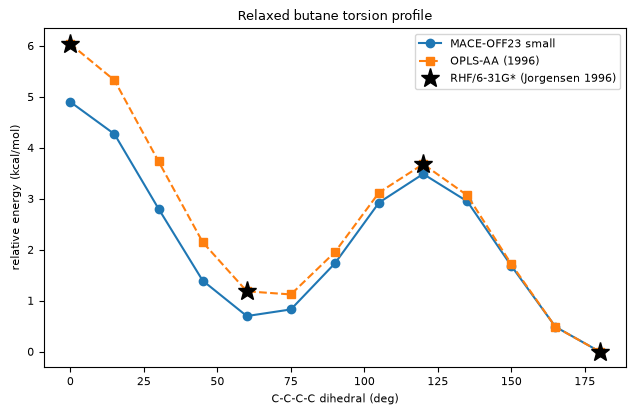

gauche-trans: OFF 0.70 vs OPLS 1.18 kcal/mol
cis barrier:  OFF 4.90 vs OPLS 6.03 kcal/mol


In [3]:
from xnn.ffnn.models import OPLS

butane_pos = np.array(
    [[0.0, 0.0, 0.0], [1.53, 0.0, 0.0], [2.05, 1.44, 0.0], [3.58, 1.44, 0.0],
     [-0.4, -0.5, 0.9], [-0.4, -0.5, -0.9], [-0.4, 1.0, 0.0],
     [1.93, -0.52, 0.88], [1.93, -0.52, -0.88],
     [1.65, 1.96, -0.88], [1.65, 1.96, 0.88],
     [3.98, 0.44, 0.0], [3.98, 1.96, 0.88], [3.98, 1.96, -0.88]])
butane_z = [6, 6, 6, 6] + [1] * 10

# OPLS-AA with the paper's 1996 alkane torsions, typed automatically
opls = OPLS.from_atoms(Atoms(numbers=butane_z, positions=butane_pos),
                       "oplsaa-1996", cutoff=25.0)
opls_calc = lambda: XNNCalculator(ForceStressOutput(opls), cutoff=opls.cutoff)


def torsion_scan(calc_factory, angles, fmax=8e-4):
    """Relaxed C-C-C-C scan with continuation between the points."""
    ref = Atoms(numbers=butane_z,
                positions=butane_pos + 0.03 * rng.standard_normal((14, 3)))
    ref.calc = calc_factory()
    assert BFGS(ref, logfile=None).run(fmax=fmax, steps=800)
    energies, current = {}, ref
    for a in angles:
        w = current.copy()
        w.calc = calc_factory()
        w.set_dihedral(0, 1, 2, 3, a, indices=[3, 11, 12, 13])
        w.rattle(0.003, seed=2)              # break saddle symmetry
        w.set_constraint(FixInternals(dihedrals_deg=[[a, [0, 1, 2, 3]]]))
        assert BFGS(w, logfile=None).run(fmax=fmax, steps=800)
        w.set_constraint()
        energies[a] = w.get_potential_energy() * EV_TO_KCAL
        current = w
    e0 = min(energies.values())
    return {a: e - e0 for a, e in energies.items()}


angles = list(range(180, -1, -15))
prof_off = torsion_scan(off_calc, angles)
prof_opls = torsion_scan(opls_calc, angles)
table1 = {0: 6.04, 60: 1.18, 120: 3.68, 180: 0.00}   # Jorgensen 1996 (RHF/6-31G*)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(angles, [prof_off[a] for a in angles], "o-", label="MACE-OFF23 small")
ax.plot(angles, [prof_opls[a] for a in angles], "s--", label="OPLS-AA (1996)")
ax.plot(list(table1), list(table1.values()), "k*", ms=14,
        label="RHF/6-31G* (Jorgensen 1996)")
ax.set_xlabel("C-C-C-C dihedral (deg)")
ax.set_ylabel("relative energy (kcal/mol)")
ax.set_title("Relaxed butane torsion profile")
ax.legend()
fig.tight_layout()
fig.savefig("mace_off_butane_torsion.png", dpi=150)
plt.show()
print(f"gauche-trans: OFF {prof_off[60]:.2f} vs OPLS {prof_opls[60]:.2f} kcal/mol")
print(f"cis barrier:  OFF {prof_off[0]:.2f} vs OPLS {prof_opls[0]:.2f} kcal/mol")
assert 0.3 < prof_off[60] < 1.2 and 3.5 < prof_off[0] < 7.0

The two potentials, built from entirely different philosophies (a
transferable ML model trained on wB97M-D3 data vs a hand-parameterized
classical force field fit to HF-level scans), agree on the qualitative
profile; the quantitative differences (gauche well, cis barrier) reflect
their different quantum-chemistry references as much as their functional
forms.

## 3. Hydrogen bonding: the water dimer

Binding energy and geometry of the H-bonded water dimer, relaxed from a
handful of acceptor orientations (the H-bond minimum competes with
repulsive arrangements, so a small orientation search is more robust than
one lucky starting guess). Reference: CCSD(T)/CBS gives
De = 4.99 kcal/mol at R(O-O) = 2.91 A.


MACE-OFF23 small: De = -4.82 kcal/mol at R(O-O) = 2.928 A
CCSD(T)/CBS:      De = -4.99 kcal/mol at R(O-O) = 2.912 A


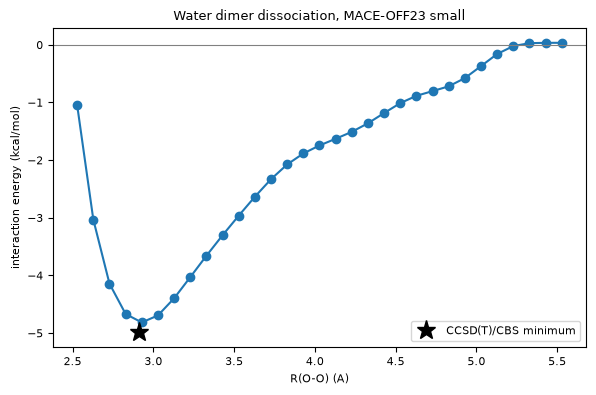

In [4]:
water = Atoms(numbers=[8, 1, 1],
              positions=[[0, 0, 0], [0.9572, 0, 0], [-0.24, 0.9266, 0]])
water.calc = off_calc()
BFGS(water, logfile=None).run(fmax=1e-4, steps=300)
e_mono = water.get_potential_energy()
mono = water.get_positions() - water.get_positions()[0]

best = None
for axis, ang in [("z", 120), ("z", -60), ("y", 120), ("y", -120), ("x", 90)]:
    acc = mono @ Rotation.from_euler(axis, ang, degrees=True).as_matrix().T \
        + np.array([2.95, 0.0, 0.0])
    dimer = Atoms(numbers=[8, 1, 1] * 2, positions=np.vstack([mono, acc]))
    dimer.calc = off_calc()
    BFGS(dimer, logfile=None).run(fmax=1e-4, steps=500)
    e = dimer.get_potential_energy()
    if best is None or e < best[0]:
        best = (e, dimer.copy())
e_dim, dimer = best
de = (e_dim - 2 * e_mono) * EV_TO_KCAL
roo = np.linalg.norm(dimer.get_positions()[3] - dimer.get_positions()[0])
print(f"MACE-OFF23 small: De = {de:.2f} kcal/mol at R(O-O) = {roo:.3f} A")
print("CCSD(T)/CBS:      De = -4.99 kcal/mol at R(O-O) = 2.912 A")
assert -6.0 < de < -3.5 and 2.8 < roo < 3.05

# the dissociation curve: rigid displacement of the acceptor along O-O
axis_vec = (dimer.get_positions()[3] - dimer.get_positions()[0])
axis_vec /= np.linalg.norm(axis_vec)
curve = {}
for dr in np.arange(-0.4, 2.61, 0.1):
    w = dimer.copy()
    p = w.get_positions()
    p[3:] += dr * axis_vec
    w.set_positions(p)
    w.calc = off_calc()
    curve[roo + dr] = (w.get_potential_energy() - 2 * e_mono) * EV_TO_KCAL

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(list(curve), list(curve.values()), "o-")
ax.axhline(0.0, color="gray", lw=0.8)
ax.plot([2.912], [-4.99], "k*", ms=14, label="CCSD(T)/CBS minimum")
ax.set_xlabel("R(O-O) (A)")
ax.set_ylabel("interaction energy (kcal/mol)")
ax.set_title("Water dimer dissociation, MACE-OFF23 small")
ax.legend()
fig.tight_layout()
fig.savefig("mace_off_water_dimer.png", dpi=150)
plt.show()

A sub-10 MB foundation model reproduces the coupled-cluster H-bond to a
couple of tenths of a kcal/mol, without a single water-specific parameter.

## 4. Fine-tuning the foundation model to a new reference

The rMD17 malonaldehyde set (`load_dataset("rmd17", ...)`) is labeled at
the PBE level; MACE-OFF23 was trained on wB97M-D3(BJ). Zero-shot, the
foundation model already has qualitatively right forces, and adapting it is
exactly the same `from_dict -> Trainer -> fit` pipeline used everywhere in
xnn: `model: {foundation: mace-off23-small, ...}` loads the pretrained
weights, and every parameter (including the transplanted ones) is
trainable.

Two practical notes, both visible in the numbers below. First, absolute
energies of different functionals differ by a large per-element constant
(~18.6 eV here for C3H4O2), so the per-element references `atom_ref` are
aligned on the training set before fitting -- otherwise the energy loss
starts astronomically far from the minimum. Second, this is a *naive* full
fine-tune on one molecule: it adapts the model to malonaldehyde at the
price of some transferability (the multi-head replay strategies used to
avoid that live in the upstream training pipeline, not in the model).


In [5]:
torch.set_default_dtype(torch.float32)   # training dtype
from xnn.common.config import from_dict
from xnn.common.data import AtomicDataset, collate, load_dataset
from xnn.common.train import Trainer

train_structs = load_dataset("rmd17", molecule="malonaldehyde", split="train")
test_structs = load_dataset("rmd17", molecule="malonaldehyde", split="test")
n_train, n_val, n_test = 200, 50, 200

cfg = from_dict({
    "model": {"name": "mace", "cutoff": 4.5,
              "foundation": "mace-off23-small", "dtype": "float32"},
    "data": {"batch_size": 10},
    "optim": {"lr": 1e-3, "epochs": 60, "energy_weight": 1.0,
              "force_weight": 10.0, "scheduler": "cosine"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/mace_off_finetune",
})
train_set = AtomicDataset(train_structs[:n_train], cutoff=cfg.model.cutoff)
val_set = AtomicDataset(train_structs[n_train:n_train + n_val],
                        cutoff=cfg.model.cutoff)
test_set = AtomicDataset(test_structs[:n_test], cutoff=cfg.model.cutoff)


def evaluate(fmodel):
    """Energy MAE (after removing the mean reference offset) + force MAE."""
    fmodel.eval()
    de, dfa = [], []
    for i0 in range(0, len(test_set), 50):
        batch = collate([test_set[i] for i in
                         range(i0, min(i0 + 50, len(test_set)))]).to(DEVICE)
        out = fmodel(batch)
        de.append((out["energy"].detach() - batch.energy).cpu())
        dfa.append((out["forces"].detach() - batch.forces).abs().mean().cpu())
    de = torch.cat(de)
    return (float((de - de.mean()).abs().mean()) * 1000 / 9,
            float(torch.stack(dfa).mean()),
            float(de.mean()))


trainer = Trainer(cfg, train_set, val_set, test_set)
e_mae0, f_mae0, offset = evaluate(trainer.module)
print(f"zero-shot: force MAE {f_mae0:.3f} eV/A | energy MAE "
      f"{e_mae0:.1f} meV/atom (after removing the {offset:+.1f} eV "
      "reference offset)")

# align the per-element references with the new dataset's energy zero
model = trainer.module.model
with torch.no_grad():
    for z in model.species:
        model.atom_ref.weight[z] += offset / 9.0
log = io.StringIO()
with contextlib.redirect_stdout(log):
    history = trainer.fit()
e_mae1, f_mae1, offset1 = evaluate(trainer.module)
print(f"fine-tuned ({cfg.optim.epochs} epochs, {n_train} structures): "
      f"force MAE {f_mae1:.3f} eV/A | energy MAE {e_mae1:.1f} meV/atom")
assert f_mae1 < 0.25 * f_mae0

rmd17:malonaldehyde train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:malonaldehyde test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:malonaldehyde train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:malonaldehyde test:   0%|          | 0/1000 [00:00<?, ? struct/s]

mace-off23-small is distributed under the Academic Software License (https://github.com/gabor1/ASL); by using it you accept its terms (no commercial use).


zero-shot: force MAE 0.403 eV/A | energy MAE 6.5 meV/atom (after removing the -18.6 eV reference offset)


fine-tuned (60 epochs, 200 structures): force MAE 0.073 eV/A | energy MAE 2.3 meV/atom


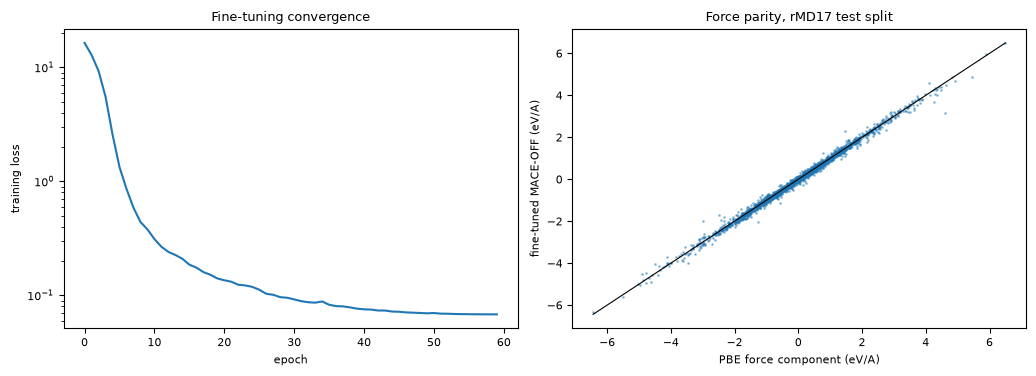

In [6]:
losses = [float(line.split("train loss")[1].split("|")[0])
          for line in log.getvalue().splitlines() if "train loss" in line]
fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.8))
ax[0].semilogy(losses)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("training loss")
ax[0].set_title("Fine-tuning convergence")

batch = collate([test_set[i] for i in range(100)]).to(DEVICE)
out = trainer.module(batch)
f_ref = batch.forces.cpu().numpy().ravel()
f_pred = out["forces"].detach().cpu().numpy().ravel()
ax[1].plot(f_ref, f_pred, ".", ms=2, alpha=0.4)
lim = [f_ref.min(), f_ref.max()]
ax[1].plot(lim, lim, "k-", lw=0.8)
ax[1].set_xlabel("PBE force component (eV/A)")
ax[1].set_ylabel("fine-tuned MACE-OFF (eV/A)")
ax[1].set_title("Force parity, rMD17 test split")
fig.tight_layout()
fig.savefig("mace_off_finetune.png", dpi=150)
plt.show()

## Summary

* `MACE.from_foundation("mace-off23-small")` gives a working, deployable
  organic potential in one line; through `XNNCalculator` it drives the same
  ASE workflows as every other xnn model.
* On butane it produces a physically sensible torsion profile alongside
  OPLS-AA; on the water dimer it reproduces the CCSD(T)/CBS hydrogen bond
  to a few tenths of a kcal/mol.
* Fine-tuning is the stock xnn `Trainer` with
  `model: {foundation: ...}` in the config: 60 epochs on 200 PBE
  structures cut the malonaldehyde force MAE by well over 4x after
  aligning the per-element energy references.

The materials-side foundation models (MACE-MP-0 through OMAT-0) get the
same treatment in `mace_foundation_materials.ipynb`.
